In [ ]:
import pandas as pd
import numpy as np

# 1. Load your file
df = pd.read_csv('Depth Data.csv')

# 2. Grab the second column as a Pandas Series (DO NOT add .values here!)
raw_column = df.iloc[:, 1]

# 3. Force Python to convert strings to numbers
numeric_depths = pd.to_numeric(raw_column, errors='coerce')

# 4. Fill any missing blank spaces while it's still a Pandas Series
# 5. NOW extract the final numeric array using .values at the very end
raw_depths = numeric_depths.ffill().bfill().values

cleaned_depths = raw_depths.copy()
glitch_threshold = 15.0
glitch_count = 0
for i in range(1, len(raw_depths) - 1):

    # Calculate the sudden change in depth from the previous second
    depth_jump = abs(raw_depths[i] - raw_depths[i-1])

    # If the jump is bigger than our threshold, it's a sensor error!
    if depth_jump > glitch_threshold:
        glitch_count += 1

        # Smooth it out: Replace the glitch with the average of the point before and after it
        # In C: cleaned_depths[i] = (raw_depths[i-1] + raw_depths[i+1]) / 2.0;
        cleaned_depths[i] = (raw_depths[i-1] + raw_depths[i+1]) / 2.0

print("--- GLITCH REMOVAL COMPLETE ---")
print(f"Identified and repaired {glitch_count} corrupt sensor spikes!")

--- GLITCH REMOVAL COMPLETE ---
Identified and repaired 93 corrupt sensor spikes!


In [ ]:
# Choose a 3-second smoothing window size
window_size = 3

# Create an array of uniform mathematical weights: [1/3, 1/3, 1/3]
weights = np.ones(window_size) / window_size

# np.convolve slides this 3-second averaging window across our data array.
# mode='same' keeps our output array the exact same length as our original data.
smoothed_depths = np.convolve(cleaned_depths, weights, mode='same')

print("--- STEP 3 COMPLETE: DATA SMOOTHING SUCCESSFUL ---")
print("First 5 Glitch-Removed Depths: ", cleaned_depths[:5])
print("First 5 Wave-Smoothed Depths:  ", smoothed_depths[:5])

--- STEP 3 COMPLETE: DATA SMOOTHING SUCCESSFUL ---
First 5 Glitch-Removed Depths:  [-263.7  -255.9  -276.05 -296.2  -290.8 ]
First 5 Wave-Smoothed Depths:   [-173.2        -265.21666667 -276.05       -287.68333333 -292.31666667]


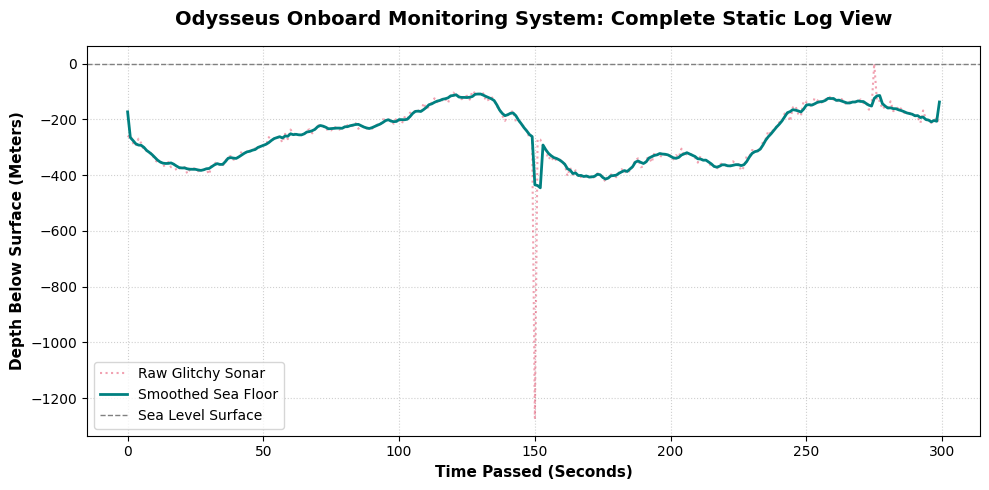

In [ ]:
import matplotlib.pyplot as plt

# 1. Initialize a clean, widescreen canvas container (10 inches wide, 5 inches tall)
fig, ax = plt.subplots(figsize=(10, 5))

# 2. Plot the raw data with glitches as a faint red dotted background line
ax.plot(raw_depths, color='crimson', linestyle=':', alpha=0.4, label='Raw Glitchy Sonar')

# 3. Plot your beautifully smoothed sea floor path as a solid teal line
ax.plot(smoothed_depths, color='teal', linestyle='-', linewidth=2, label='Smoothed Sea Floor')

# 4. Draw a static safety reference line representing the ocean surface at 0
ax.axhline(0, color='gray', linestyle='--', linewidth=1, label='Sea Level Surface')

# 5. Add formal layout details and axis labels
ax.set_title("Odysseus Onboard Monitoring System: Complete Static Log View", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Time Passed (Seconds)", fontsize=11, fontweight='bold')
ax.set_ylabel("Depth Below Surface (Meters)", fontsize=11, fontweight='bold')
# 6. Add visual layout aids for high scannability
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='lower left')

# 7. Clean up padding and render the completed chart interface
plt.tight_layout()
plt.show()